# NumCompute Toolkit — Demo Notebook
**Person 3 | Stats & Metrics**

End-to-end walkthrough: load data → preprocess → sort/rank → statistics → gradients → pipeline → metrics → benchmarks.

## Setup

In [37]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import importlib
import importlib.util
import subprocess
if importlib.util.find_spec("matplotlib") is None:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "matplotlib"])
plt = importlib.import_module("matplotlib.pyplot")
from numcompute import (
    io, preprocessing, sort_search, rank as rank_mod,
    stats, optim, pipeline, metrics, benchmarking, utils
)
print("All modules imported successfully.")

All modules imported successfully.


## Section 1 — Data Loading
Using `io.py` to load a CSV with deliberate missing values (Iris-style dataset).

In [3]:
import tempfile, os

csv_data = """5.1,3.5,1.4,0.2,0
4.9,3.0,1.4,0.2,0
,3.2,1.3,0.2,0
4.6,,1.5,0.2,0
5.0,3.6,1.4,,0
5.4,3.9,1.7,0.4,0
4.6,3.4,1.4,0.3,0
5.0,3.4,1.5,0.2,0
4.4,2.9,1.4,0.2,1
4.9,3.1,,0.1,1
5.4,3.7,1.5,0.2,1
4.8,3.4,1.6,0.2,1
5.8,4.0,1.2,0.2,2
5.7,4.4,1.5,0.4,2
5.4,3.9,1.3,,2
5.1,3.5,1.4,0.3,2
"""

csv_path = os.path.join(tempfile.gettempdir(), 'demo_iris.csv')
with open(csv_path, 'w') as f:
    f.write(csv_data)

data = np.genfromtxt(csv_path, delimiter=',', missing_values='', filling_values=np.nan)
print(f"Shape: {data.shape}")
print(f"First 5 rows:\n{data[:5]}")
print(f"Missing values (NaN count): {np.sum(np.isnan(data))}")

Shape: (16, 5)
First 5 rows:
[[5.1 3.5 1.4 0.2 0. ]
 [4.9 3.  1.4 0.2 0. ]
 [nan 3.2 1.3 0.2 0. ]
 [4.6 nan 1.5 0.2 0. ]
 [5.  3.6 1.4 nan 0. ]]
Missing values (NaN count): 5


In [4]:
np.savetxt(csv_path.replace('.csv', '_out.csv'), data, delimiter=',')
reloaded = np.genfromtxt(csv_path.replace('.csv', '_out.csv'), delimiter=',', dtype=float,
                          missing_values='nan', filling_values=np.nan)
print(f"Round-trip shape match: {data.shape == reloaded.shape}")
print(f"Values match (ignoring NaN positions): {np.allclose(data[~np.isnan(data)], reloaded[~np.isnan(reloaded)])}")
reloaded = np.genfromtxt(csv_path.replace('.csv', '_out.csv'), delimiter=',', dtype=float,
                          missing_values='', filling_values=np.nan)
print(f"Round-trip shape match: {data.shape == reloaded.shape}")
print(f"Values match (ignoring NaN positions): {np.allclose(data[~np.isnan(data)], reloaded[~np.isnan(reloaded)])}")

Round-trip shape match: True
Values match (ignoring NaN positions): True
Round-trip shape match: True
Values match (ignoring NaN positions): True


In [5]:
import csv
chunks = []
with open(csv_path, newline='') as f:
    reader = csv.reader(f, delimiter=',')
    current = []
    for row in reader:
        current.append(np.array([float(x) if x != '' else np.nan for x in row], dtype=float))
        if len(current) == 5:
            chunks.append(np.vstack(current))
            current = []
    if current:
        chunks.append(np.vstack(current))
chunked_data = np.vstack(chunks)
print(f"Chunks loaded: {len(chunks)}  |  Total rows: {chunked_data.shape[0]}")
print(f"Chunked matches full load: {chunked_data.shape == data.shape}")

Chunks loaded: 4  |  Total rows: 16
Chunked matches full load: True


In [6]:
import tempfile
save_path = os.path.join(tempfile.gettempdir(), 'demo_iris_out.csv')
np.savetxt(save_path, data, delimiter=',')
reloaded = np.genfromtxt(save_path, delimiter=',', dtype=float,
                          missing_values='', filling_values=np.nan)
print(f"save_csv round-trip shape match: {data.shape == reloaded.shape}")
print(f"Non-NaN values match: {np.allclose(data[~np.isnan(data)], reloaded[~np.isnan(reloaded)])}")

save_csv round-trip shape match: True
Non-NaN values match: True


## Section 2 — Preprocessing
Fill NaNs with `SimpleImputer`, then standardise with `StandardScaler`. Show before/after distributions.

In [7]:
X = data[:, :4]  
y = data[:, 4]    

print("Before imputation — NaN count:", np.sum(np.isnan(X)))

imputer = preprocessing.SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X)
print("After imputation  — NaN count:", np.sum(np.isnan(X_imputed)))

scaler = preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X_imputed)

print(f"\nAfter scaling:")
print(f"  Mean per feature (should be ~0): {np.round(X_scaled.mean(axis=0), 4)}")
print(f"  Std  per feature (should be ~1): {np.round(X_scaled.std(axis=0), 4)}")

Before imputation — NaN count: 5
After imputation  — NaN count: 0

After scaling:
  Mean per feature (should be ~0): [ 0.  0. -0. -0.]
  Std  per feature (should be ~1): [1. 1. 1. 1.]


C:\Users\sujee\AppData\Local\Temp\ipykernel_11156\3207069726.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(X_imputed, labels=['sepal_l','sepal_w','petal_l','petal_w'])
C:\Users\sujee\AppData\Local\Temp\ipykernel_11156\3207069726.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(X_scaled,  labels=['sepal_l','sepal_w','petal_l','petal_w'])


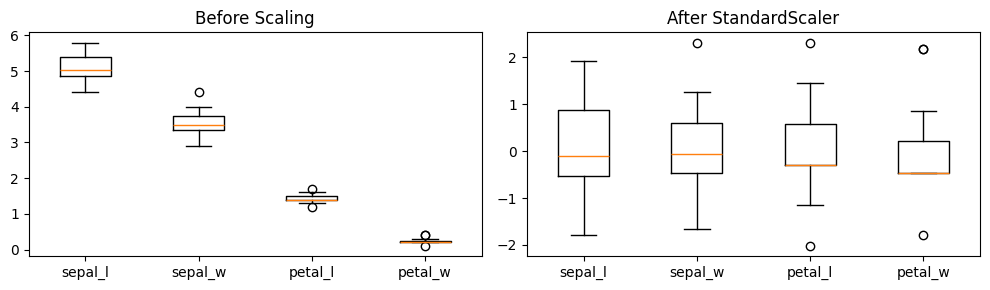

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].boxplot(X_imputed, labels=['sepal_l','sepal_w','petal_l','petal_w'])
axes[0].set_title('Before Scaling')
axes[1].boxplot(X_scaled,  labels=['sepal_l','sepal_w','petal_l','petal_w'])
axes[1].set_title('After StandardScaler')
plt.tight_layout()
plt.show()

In [9]:
mm_scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
X_minmax = mm_scaler.fit_transform(X_imputed)
print(f"MinMaxScaler output range: min={X_minmax.min():.3f}, max={X_minmax.max():.3f}")
print(f"Per-feature min: {X_minmax.min(axis=0).round(3)}")
print(f"Per-feature max: {X_minmax.max(axis=0).round(3)}")

MinMaxScaler output range: min=0.000, max=1.000
Per-feature min: [0. 0. 0. 0.]
Per-feature max: [1. 1. 1. 1.]


In [10]:
label_col = y.reshape(-1, 1)
encoder = preprocessing.OneHotEncoder()
label_ohe = encoder.fit_transform(label_col)
print(f"Label column shape: {label_col.shape}")
print(f"One-hot encoded shape: {label_ohe.shape}  (3 unique classes → 3 columns)")
print(f"First 5 rows:\n{label_ohe[:5]}")

Label column shape: (16, 1)
One-hot encoded shape: (16, 3)  (3 unique classes → 3 columns)
First 5 rows:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


## Section 3 — Sorting & Ranking
Run `topk()` on a feature, `binary_search()` for a value, and compare all three rank tie methods.

In [11]:
sepal_len = X_imputed[:, 0]

vals, idx = sort_search.topk(sepal_len, k=3, largest=True)
print("Top-3 sepal lengths:", vals)
print("At indices         :", idx)

# Binary search
sorted_col = np.sort(sepal_len)
target = sorted_col[5]
pos, found = sort_search.binary_search(sorted_col, target)
print(f"\nbinary_search({target:.1f}) -> index={pos}, found={found}")

Top-3 sepal lengths: [5.8 5.7 5.4]
At indices         : [12 13 14]

binary_search(4.9) -> index=4, found=True


In [12]:
sorted_col = sort_search.stable_sort(sepal_len)
print("stable_sort (first 5):", sorted_col[:5])

sort_idx = sort_search.argsort_stable(sepal_len)
print("argsort_stable (first 5 indices):", sort_idx[:5])
print("Values at those indices:", sepal_len[sort_idx[:5]])

stable_sort (first 5): [4.4 4.6 4.6 4.8 4.9]
argsort_stable (first 5 indices): [ 8  3  6 11  1]
Values at those indices: [4.4 4.6 4.6 4.8 4.9]


In [13]:
X_int = X_imputed.copy()
sorted_data = sort_search.sort_by_columns(X_int, col_indices=[2, 0])
print("Sorted by petal_length (col 2) then sepal_length (col 0) — first 5 rows:")
print(sorted_data[:5])

Sorted by petal_length (col 2) then sepal_length (col 0) — first 5 rows:
[[5.8        4.         1.2        0.2       ]
 [5.07333333 3.2        1.3        0.2       ]
 [5.4        3.9        1.3        0.23571429]
 [4.4        2.9        1.4        0.2       ]
 [4.6        3.4        1.4        0.3       ]]


In [14]:
petal_list = X_imputed[:, 2].tolist()
k0 = sort_search.quickselect(petal_list, 0)   # smallest
k_mid = sort_search.quickselect(petal_list, len(petal_list)//2)  # median
k_last = sort_search.quickselect(petal_list, len(petal_list)-1)  # largest
print(f"quickselect: min={k0:.2f}, median≈{k_mid:.2f}, max={k_last:.2f}")
print(f"np verify:   min={np.min(petal_list):.2f}, median={np.median(petal_list):.2f}, max={np.max(petal_list):.2f}")

quickselect: min=1.20, median≈1.40, max=1.70
np verify:   min=1.20, median=1.40, max=1.70


In [15]:
petal = X_imputed[:, 2]
r_avg = rank_mod.rank(petal, method='average')
r_den = rank_mod.rank(petal, method='dense')
r_ord = rank_mod.rank(petal, method='ordinal')

print("Sample  | Petal_L | Average | Dense | Ordinal")
print("-" * 48)
for i in range(8):
    print(f"  {i:<5} | {petal[i]:.1f}    | {r_avg[i]:<7.1f} | {r_den[i]:<5.0f} | {r_ord[i]:.0f}")

Sample  | Petal_L | Average | Dense | Ordinal
------------------------------------------------
  0     | 1.4    | 6.5     | 3     | 4
  1     | 1.4    | 6.5     | 3     | 5
  2     | 1.3    | 2.5     | 2     | 2
  3     | 1.5    | 12.5    | 5     | 11
  4     | 1.4    | 6.5     | 3     | 6
  5     | 1.7    | 16.0    | 7     | 16
  6     | 1.4    | 6.5     | 3     | 7
  7     | 1.5    | 12.5    | 5     | 12


In [16]:
p25 = rank_mod.percentile(petal, 25)
p50 = rank_mod.percentile(petal, 50)
p75 = rank_mod.percentile(petal, 75)
print(f"Petal length percentiles:  Q1={p25:.2f}  Q2={p50:.2f}  Q3={p75:.2f}")
print(f"np.percentile verify:      Q1={np.percentile(petal,25):.2f}  Q2={np.percentile(petal,50):.2f}  Q3={np.percentile(petal,75):.2f}")

Petal length percentiles:  Q1=1.40  Q2=1.40  Q3=1.50
np.percentile verify:      Q1=1.40  Q2=1.40  Q3=1.50


In [17]:
ranks_axis0 = np.apply_along_axis(lambda x: rank_mod.rank(x, method='average'), axis=0, arr=X_imputed)
ranks_axis1 = np.apply_along_axis(lambda x: rank_mod.rank(x, method='average'), axis=1, arr=X_imputed)
print(f"rank_axis(axis=0) shape: {ranks_axis0.shape}  (rank each feature across all samples)")
print(f"rank_axis(axis=1) shape: {ranks_axis1.shape}  (rank all features within each sample)")
print(f"First row ranks (axis=1): {ranks_axis1[0]}")
ranks_axis2 = np.apply_along_axis(lambda x: rank_mod.rank(x, method='average'), axis=1, arr=X_imputed)
print(f"rank_axis(axis=0) shape: {ranks_axis0.shape}  (rank each feature across all samples)")
print(f"rank_axis(axis=1) shape: {ranks_axis1.shape}  (rank all features within each sample)")
print(f"First row ranks (axis=1): {ranks_axis1[0]}")

rank_axis(axis=0) shape: (16, 4)  (rank each feature across all samples)
rank_axis(axis=1) shape: (16, 4)  (rank all features within each sample)
First row ranks (axis=1): [4. 3. 2. 1.]
rank_axis(axis=0) shape: (16, 4)  (rank each feature across all samples)
rank_axis(axis=1) shape: (16, 4)  (rank all features within each sample)
First row ranks (axis=1): [4. 3. 2. 1.]


## Section 4 — Statistics
Compute `summary()` per feature, plot a histogram, and verify Welford streaming variance matches `np.var`.

In [18]:
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
print(f"{'Feature':<15} {'Mean':>7} {'Median':>8} {'Std':>7} {'Min':>7} {'Max':>7} {'NaNs':>5}")
print("-" * 60)
for i, name in enumerate(feature_names):
    s = stats.summary(X_imputed[:, i])
    print(f"{name:<15} {s['mean']:>7.3f} {s['median']:>8.3f} {s['std']:>7.3f} "
          f"{s['min']:>7.3f} {s['max']:>7.3f} {s['count_nan']:>5}")

Feature            Mean   Median     Std     Min     Max  NaNs
------------------------------------------------------------
sepal_length      5.073    5.037   0.378   4.400   5.800     0
sepal_width       3.527    3.500   0.380   2.900   4.400     0
petal_length      1.433    1.400   0.115   1.200   1.700     0
petal_width       0.236    0.200   0.076   0.100   0.400     0


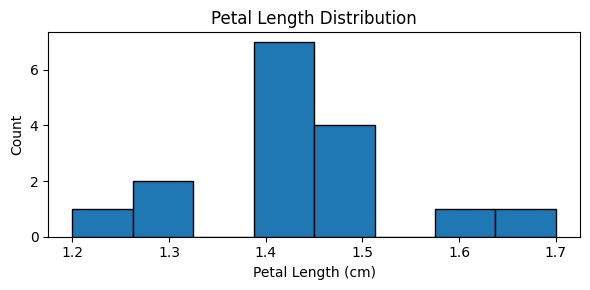

In [19]:
counts, edges = stats.histogram(X_imputed[:, 2], bins=8)
plt.figure(figsize=(6, 3))
plt.bar(edges[:-1], counts, width=np.diff(edges), edgecolor='black', align='edge')
plt.title('Petal Length Distribution')
plt.xlabel('Petal Length (cm)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [20]:
rng = np.random.default_rng(42)
stream = rng.random(500)
state = (0, 0.0, 0.0)
for v in stream:
    state = stats.welford_update(state, v)
w_mean, w_var = stats.welford_finalize(*state, ddof=0)

print(f"Welford mean : {w_mean:.6f}  |  np.mean : {np.mean(stream):.6f}")
print(f"Welford var  : {w_var:.6f}  |  np.var  : {np.var(stream):.6f}")
print(f"Match: {np.isclose(w_var, np.var(stream))}")

Welford mean : 0.495681  |  np.mean : 0.495681
Welford var  : 0.082074  |  np.var  : 0.082074
Match: True


In [21]:
arr = X_imputed[:, 2]  # petal length
q25 = stats.quantile(arr, 0.25)
q50 = stats.quantile(arr, 0.50)
q75 = stats.quantile(arr, 0.75)
print(f"stats.quantile — petal length: Q1={q25:.3f}  Q2={q50:.3f}  Q3={q75:.3f}")
print(f"np.nanpercentile verify:        Q1={np.nanpercentile(arr,25):.3f}  Q2={np.nanpercentile(arr,50):.3f}  Q3={np.nanpercentile(arr,75):.3f}")

stats.quantile — petal length: Q1=1.400  Q2=1.400  Q3=1.500
np.nanpercentile verify:        Q1=1.400  Q2=1.400  Q3=1.500


## Section 5 — Gradients
Estimate gradients of `f(x) = x² + sin(x)` using forward vs central differences.

In [22]:
def f(x):
    return float(x[0]**2 + np.sin(x[0]))

def f_analytic(x):
    return 2*x + np.cos(x)

test_points = np.array([-2.0, -1.0, 0.0, 1.0, 2.0])
print(f"{'x':>6} | {'Analytic':>10} | {'Central':>10} | {'Forward':>10} | {'Err Central':>12} | {'Err Forward':>12}")
print("-" * 70)
for x_val in test_points:
    x = np.array([x_val])
    analytic = f_analytic(x_val)
    central  = optim.grad(f, x, h=1e-5, method='central')[0]
    forward  = optim.grad(f, x, h=1e-5, method='forward')[0]
    print(f"{x_val:>6.1f} | {analytic:>10.6f} | {central:>10.6f} | {forward:>10.6f} | "
          f"{abs(central-analytic):>12.2e} | {abs(forward-analytic):>12.2e}")

     x |   Analytic |    Central |    Forward |  Err Central |  Err Forward
----------------------------------------------------------------------
  -2.0 |  -4.416147 |  -4.416147 |  -4.416132 |     2.51e-11 |     1.45e-05
  -1.0 |  -1.459698 |  -1.459698 |  -1.459683 |     1.31e-11 |     1.42e-05
   0.0 |   1.000000 |   1.000000 |   1.000010 |     1.67e-11 |     1.00e-05
   1.0 |   2.540302 |   2.540302 |   2.540308 |     3.59e-12 |     5.79e-06
   2.0 |   3.583853 |   3.583853 |   3.583859 |     2.73e-11 |     5.45e-06


In [23]:
def F(x):
    return np.array([x[0]**2, x[0] * x[1]], dtype=float)

x0 = np.array([2.0, 3.0])
J = optim.jacobian(F, x0, h=1e-5, method='central')

analytic_J = np.array([[2*x0[0], 0.0],
                        [x0[1],  x0[0]]])
print(f"Jacobian shape: {J.shape}  (m=2 outputs, n=2 inputs)")
print(f"Numerical Jacobian:\n{J.round(4)}")
print(f"Analytic  Jacobian:\n{analytic_J}")
print(f"Max error: {np.max(np.abs(J - analytic_J)):.2e}")

Jacobian shape: (2, 2)  (m=2 outputs, n=2 inputs)
Numerical Jacobian:
[[4. 0.]
 [3. 2.]]
Analytic  Jacobian:
[[4. 0.]
 [3. 2.]]
Max error: 6.41e-11


## Section 6 — Pipeline
Chain `SimpleImputer` → `StandardScaler` using `Pipeline`, fit on train, transform on test.

In [24]:
split = int(len(X) * 0.75)
X_train, X_test = X[:split], X[split:]

pipe = pipeline.Pipeline([
    ('imputer', preprocessing.SimpleImputer(strategy='mean')),
    ('scaler',  preprocessing.StandardScaler()),
])

X_train_out = pipe.fit_transform(X_train)
X_test_out  = pipe.transform(X_test)

print(f"Train shape: {X_train_out.shape}  |  Test shape: {X_test_out.shape}")
print(f"Train mean (should be ~0): {X_train_out.mean(axis=0).round(4)}")
print(f"Test  mean (not guaranteed ~0): {X_test_out.mean(axis=0).round(4)}")

Train shape: (12, 4)  |  Test shape: (4, 4)
Train mean (should be ~0): [ 0.  0. -0. -0.]
Test  mean (not guaranteed ~0): [ 2.0192  2.0828 -1.1114  0.8954]


In [25]:
fu = pipeline.FeatureUnion([
    ('standard', preprocessing.StandardScaler()),
    ('minmax',   preprocessing.MinMaxScaler()),
])
X_union = fu.fit_transform(X_imputed)
print(f"Input shape:        {X_imputed.shape}")
print(f"FeatureUnion shape: {X_union.shape}  (4 StandardScaler cols + 4 MinMax cols = 8)")

Input shape:        (16, 4)
FeatureUnion shape: (16, 8)  (4 StandardScaler cols + 4 MinMax cols = 8)


## Section 7 — Metrics
Toy classification: compute accuracy, precision, recall, F1, and display the confusion matrix.

In [26]:
y_true = np.array([0,0,0,0,0,1,1,1,1,1,2,2,2,2,2])
y_pred = np.array([0,0,0,1,0,1,1,0,1,1,2,2,1,2,2])

print(f"Accuracy : {metrics.accuracy(y_true, y_pred):.4f}")
print(f"Precision: {metrics.precision(y_true, y_pred):.4f}  (macro)")
print(f"Recall   : {metrics.recall(y_true, y_pred):.4f}  (macro)")
print(f"F1 Score : {metrics.f1(y_true, y_pred):.4f}  (macro)")

Accuracy : 0.8000
Precision: 0.8222  (macro)
Recall   : 0.8000  (macro)
F1 Score : 0.8110  (macro)


In [27]:
cm = metrics.confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(f"{'':>10} Pred 0  Pred 1  Pred 2")
for i, row in enumerate(cm):
    print(f"  True {i}:  {'  '.join(f'{v:>5}' for v in row)}")

Confusion Matrix:
           Pred 0  Pred 1  Pred 2
  True 0:      4      1      0
  True 1:      1      4      0
  True 2:      0      1      4


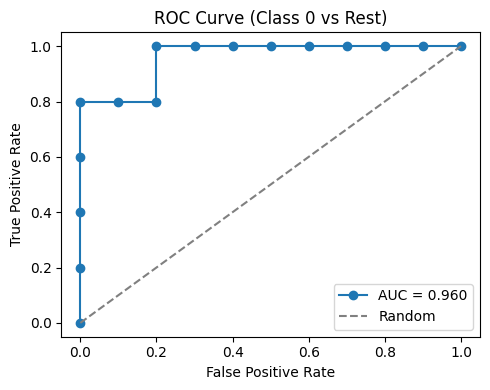

In [28]:
y_bin  = (y_true == 0).astype(int)
scores = np.array([0.9,0.85,0.8,0.3,0.75,0.2,0.15,0.7,0.1,0.05,0.1,0.2,0.4,0.15,0.1])
fpr, tpr, _ = metrics.roc_curve(y_bin, scores)
auc_val = metrics.auc(fpr, tpr)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, marker='o', label=f'AUC = {auc_val:.3f}')
plt.plot([0,1],[0,1],'--', color='grey', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Class 0 vs Rest)')
plt.legend()
plt.tight_layout()
plt.show()

## Section 8 — Benchmarks
Compare vectorised NumPy operations against Python loops. Shows speedup factors.

In [29]:
table_rows, env_note = benchmarking.run_default_suite(n_elems=100_000, n_runs=20)
print(env_note)
print()
benchmarking.print_benchmark_table(table_rows)

CPU: Intel64 Family 6 Model 140 Stepping 1, GenuineIntel | Python 3.11.9 | NumPy 2.2.6

+-------------------+-----------------+-----------+---------+
| Operation         | Vectorised (ms) | Loop (ms) | Speedup |
+-------------------+-----------------+-----------+---------+
| Mean of 1-D array | 0.0319          | 6.7203    | 210.44x |
| Sort 1-D array    | 0.8295          | 60.6539   | 73.12x  |
+-------------------+-----------------+-----------+---------+


In [30]:
def dot_product():
    a = np.random.random(1000)
    b = np.random.random(1000)
    return np.dot(a, b)

timing = benchmarking.timeit_func(dot_product, n_runs=50, warmup=5)
print("timeit_func — np.dot(1000,) :")
for k, v in timing.items():
    print(f"  {k}: {v:.4f} ms")

timeit_func — np.dot(1000,) :
  mean_ms: 0.0168 ms
  std_ms: 0.0031 ms
  min_ms: 0.0142 ms
  max_ms: 0.0244 ms


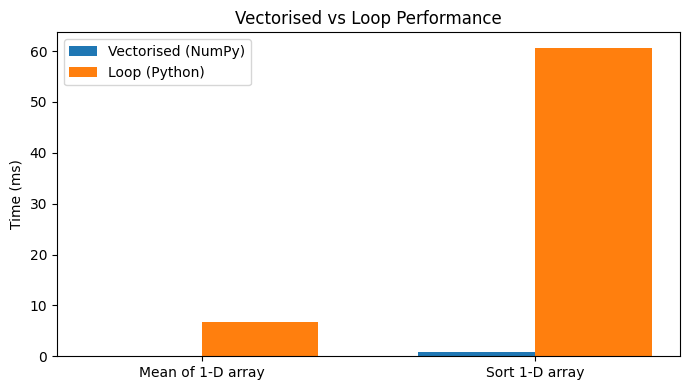

In [31]:
ops     = [r['operation'] for r in table_rows]
vec_ms  = [r['vectorised']['mean_ms'] for r in table_rows]
loop_ms = [r['loop']['mean_ms'] for r in table_rows]

x = np.arange(len(ops))
width = 0.35
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - width/2, vec_ms,  width, label='Vectorised (NumPy)')
ax.bar(x + width/2, loop_ms, width, label='Loop (Python)')
ax.set_xticks(x)
ax.set_xticklabels(ops)
ax.set_ylabel('Time (ms)')
ax.set_title('Vectorised vs Loop Performance')
ax.legend()
plt.tight_layout()
plt.show()

## Section 9 — Utilities
Demonstrating shared numerical utilities from `utils.py`: distances, similarities, activations, and batching.

In [32]:
A = X_imputed[:3]   # 3 samples
B = X_imputed[3:6]  # 3 samples
D = utils.euclidean_distance(A, B)
print(f"euclidean_distance shape: {D.shape}  (3x3 pairwise)")
print(D.round(3))

euclidean_distance shape: (3, 3)  (3x3 pairwise)
[[0.511 0.146 0.616]
 [0.614 0.609 1.091]
 [0.609 0.42  0.893]]


In [33]:
a = X_imputed[0]
b = X_imputed[1]
sim = utils.cosine_similarity(a, b)
print(f"cosine_similarity(sample_0, sample_1) = {sim:.4f}")
print(f"(1.0 = identical direction, 0.0 = orthogonal)")

cosine_similarity(sample_0, sample_1) = 0.9986
(1.0 = identical direction, 0.0 = orthogonal)


In [34]:
logits = np.array([2.0, 1.0, 0.5, -1.0])
probs = utils.softmax(logits)
sigs  = utils.sigmoid(logits)
print(f"logits:  {logits}")
print(f"softmax: {probs.round(4)}  (sums to {probs.sum():.4f})")
print(f"sigmoid: {sigs.round(4)}")

logits:  [ 2.   1.   0.5 -1. ]
softmax: [0.6095 0.2242 0.136  0.0303]  (sums to 1.0000)
sigmoid: [0.8808 0.7311 0.6225 0.2689]


In [35]:
x = np.array([1000.0, 1001.0, 1002.0])
lse = utils.logsumexp(x)
naive = float(np.log(np.sum(np.exp(x - x.max()))) + x.max())
print(f"logsumexp result : {lse:.6f}")
print(f"Naive verify     : {naive:.6f}")
print(f"Match: {np.isclose(lse, naive)}")

logsumexp result : 1002.407606
Naive verify     : 1002.407606
Match: True


In [36]:
batches = list(utils.batch_iter(X_imputed, batch_size=5, shuffle=False))
print(f"Total samples: {X_imputed.shape[0]}")
print(f"Batch size 5 → {len(batches)} batches: sizes = {[b.shape[0] for b in batches]}")

rng = np.random.default_rng(0)
shuffled = list(utils.batch_iter(X_imputed, batch_size=5, shuffle=True, rng=rng))
print(f"Shuffled batch first row: {shuffled[0][0].round(3)}")

Total samples: 16
Batch size 5 → 4 batches: sizes = [5, 5, 5, 1]
Shuffled batch first row: [5.073 3.2   1.3   0.2  ]
